In [2]:
import torch

# To fix the problem: stuck at building wheels while installing torch-cluster
# Reference: https://stackoverflow.com/questions/67285115/building-wheels-for-torch-sparse-in-colab-takes-forever
!pip uninstall torch-scatter torch-sparse torch-geometric torch-cluster  --y
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git

Found existing installation: torch_scatter 2.1.2
Uninstalling torch_scatter-2.1.2:
  Successfully uninstalled torch_scatter-2.1.2
Found existing installation: torch_sparse 0.6.18
Uninstalling torch_sparse-0.6.18:
  Successfully uninstalled torch_sparse-0.6.18
Found existing installation: torch_cluster 1.6.3
Uninstalling torch_cluster-1.6.3:
  Successfully uninstalled torch_cluster-1.6.3
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
  Using cached torch_scatter-2.1.2-cp311-cp311-linux_x86_64.whl
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
  Using cached torch_sparse-0.6.18-cp311-cp311-linux_x86_64.whl
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
  Using cached torch_cluster-1.6.3-cp311-cp311-linux_x86_64.whl
  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-4li_9nhx
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-4li_9

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch_geometric.transforms as T
from torch_geometric.data import Data
from torch_geometric.nn import DynamicEdgeConv, EdgeConv, global_mean_pool
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

In [4]:
K = 5
class DGCNN(nn.Module):
  def __init__(self, in_channels, hidden_channels, out_channels, k=K):
    super(DGCNN, self).__init__()
    self.conv1 = EdgeConv(nn.Sequential(
      nn.Linear(2 * in_channels, hidden_channels),
      nn.ReLU(),
      nn.Linear(hidden_channels, hidden_channels),
      nn.ReLU()
    ), aggr='add')
    self.conv2 = EdgeConv(nn.Sequential(
      nn.Linear(2 * hidden_channels, hidden_channels),
      nn.ReLU(),
      nn.Linear(hidden_channels, hidden_channels),
      nn.ReLU()
    ), aggr='add')
    self.fc = nn.Sequential(
      nn.Linear(hidden_channels, 64),
      nn.ReLU(),
      nn.Linear(64, out_channels),
    )

  def forward(self, data):
    x, edge_index = data.x, data.edge_index
    # print(edge_index[0,:K]) # to track whether the nearest neighbours are changing
    x = self.conv1(x, edge_index)
    edge_index = knn_graph(x, k=K, loop=True)
    # print(edge_index[0,:K]) # to track whether the nearest neighbours are changing
    x = self.conv2(x, edge_index)

    x = self.fc(x)
    return x


## Splitting

In [5]:
from torch_cluster import knn_graph

# Load CSV
df = pd.read_csv("crime_data_by_community_areas.csv")
display(df)

# Normalize centroid features
X = df[['centroid_x', 'centroid_y']]
y = df['crime_count']
scaler = StandardScaler()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Convert to tensor
X_train = torch.tensor(X_train, dtype=torch.float)
X_val = torch.tensor(X_val, dtype=torch.float)
y_train = torch.tensor(y_train.values, dtype=torch.float).view(-1, 1)
y_val = torch.tensor(y_val.values, dtype=torch.float).view(-1, 1)

# Create edges using KNN adjacency
edge_index_train = knn_graph(X_train, k=K, loop=True)
edge_index_val = knn_graph(X_val, k=K, loop=True)


train_graph = Data(x=X_train, edge_index=edge_index_train, y=y_train)
val_graph = Data(x=X_val, edge_index=edge_index_val, y=y_val)

def create_dataloader(graph, batch_size=1):
  dataset = [graph]  # We only have a single graph
  return DataLoader(dataset, batch_size=batch_size, shuffle=True) # this is trivial for this part

train_loader = create_dataloader(train_graph)
val_loader = create_dataloader(val_graph)

# for batch in train_loader:
#   print(batch)
#   print(batch.batch)
#   print(batch.ptr)
#   break
# len(train_loader)

,area_id,centroid_x,centroid_y,crime_count
0,35,1.179004e+06,1.883317e+06,85070
1,36,1.183252e+06,1.879210e+06,18108
2,37,1.175335e+06,1.873800e+06,25025
3,38,1.179294e+06,1.875241e+06,105922
4,39,1.185216e+06,1.873821e+06,45108
...,...,...,...,...
72,74,1.153615e+06,1.832015e+06,17050
73,75,1.165684e+06,1.830229e+06,60613
74,76,1.103795e+06,1.934036e+06,46737
75,77,1.166380e+06,1.938460e+06,77885


Epoch 0, Train-Loss:	 18651871232.0000
Epoch 0, Val-Loss:	 7816327168.0000
Epoch 500, Train-Loss:	 8436021760.0000
Epoch 500, Val-Loss:	 4094110720.0000
Epoch 1000, Train-Loss:	 7275467264.0000
Epoch 1000, Val-Loss:	 3913375232.0000
Epoch 1500, Train-Loss:	 5847394304.0000
Epoch 1500, Val-Loss:	 4562667520.0000
Epoch 2000, Train-Loss:	 4001529344.0000
Epoch 2000, Val-Loss:	 5607583232.0000
Epoch 2500, Train-Loss:	 1644091648.0000
Epoch 2500, Val-Loss:	 5151078912.0000
Epoch 3000, Train-Loss:	 234104976.0000
Epoch 3000, Val-Loss:	 10158784512.0000


Text(0.5, 1.0, 'Training and Validation Loss')

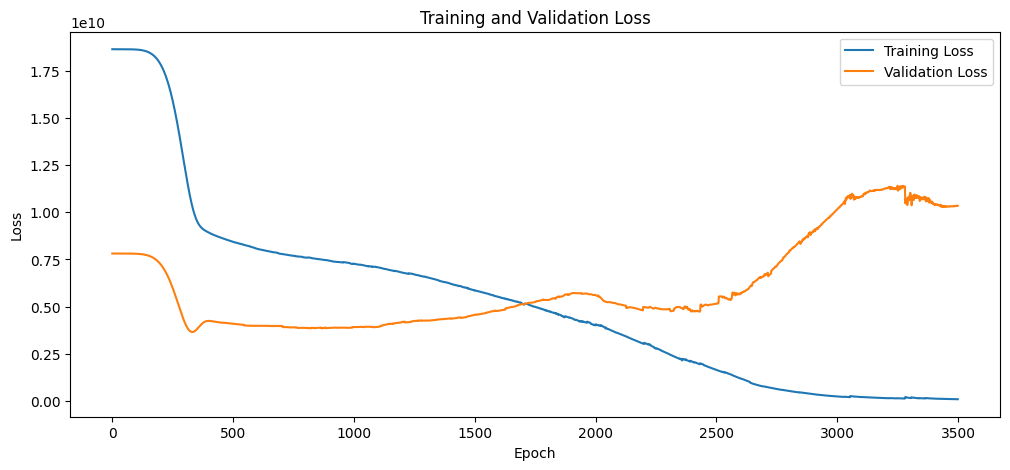

In [6]:
torch.manual_seed(0)
# Model, Loss & Optimizer
model = DGCNN(in_channels=2, hidden_channels=128, out_channels=1)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

train_losses = []
val_losses = []
# Training Loop
def train(model, train_loader, val_loader, optimizer, loss_fn, epochs=1000):
  for epoch in range(epochs):
    model.train()
    running_train_loss=0
    for data in train_loader:
      output = model(data)
      loss = loss_fn(output, data.y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      running_train_loss += loss.item()
    train_losses.append(running_train_loss / len(train_loader))

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
      for data in val_loader:
        output = model(data)
        loss = loss_fn(output, data.y)
        running_val_loss += loss.item()
      val_losses.append(running_val_loss / len(val_loader))

    if epoch % 500 == 0:
      print(f"Epoch {epoch}, Train-Loss:\t {train_losses[-1]:.4f}")
      print(f"Epoch {epoch}, Val-Loss:\t {val_losses[-1]:.4f}")


epochs = 3500
train(model, train_loader, val_loader, optimizer, loss_fn, epochs)


import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')


In [7]:
# outputs = trainloader.dataset.
train_data = train_loader.dataset[0]
val_data = val_loader.dataset[0]

model.eval()
train_predictions = model(train_data)
val_predictions = model(val_data)

# train_data.y.T.squeeze()
train_result = pd.DataFrame({'train_target': train_data.y.squeeze(), 'train_prediction': train_predictions.squeeze().detach()})
val_result =  pd.DataFrame({'val_target': val_data.y.squeeze(), 'val_prediction': val_predictions.squeeze().detach()})

display(train_result)
display(val_result)


,train_target,train_prediction
0,157654.0,143448.750000
1,139263.0,151452.078125
2,37857.0,29012.408203
3,251264.0,242160.828125
4,30527.0,41572.179688
...,...,...
56,60613.0,62819.222656
57,118682.0,132196.046875
58,213266.0,213164.828125
59,44801.0,53662.156250


,val_target,val_prediction
0,30960.0,52605.410156
1,46737.0,40093.511719
2,29379.0,46721.511719
3,63229.0,39126.746094
4,29126.0,95629.757812
5,142250.0,186665.796875
6,69250.0,136669.390625
7,60267.0,131232.468750
8,41677.0,172781.296875
9,214803.0,327768.750000


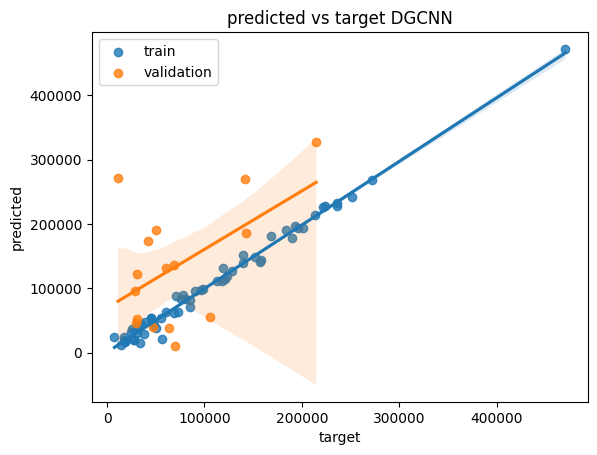

In [8]:

import seaborn as sns
ax = sns.regplot(x=train_data.y.squeeze().numpy(), y= train_predictions.squeeze().detach().numpy(), label='train')

ax = sns.regplot(x=val_data.y.squeeze().numpy(), y= val_predictions.squeeze().detach().numpy(), label='validation')
ax.set(title = 'predicted vs target DGCNN', xlabel='target', ylabel='predicted')
ax.legend()


# Comparing with other statistical models

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [47]:
df = pd.read_csv("crime_data_by_community_areas.csv")


X = df[['centroid_x', 'centroid_y']]
y = df['crime_count']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the PolynomialFeatures and StandardScaler
poly = PolynomialFeatures(degree=2, include_bias=False)
scaler = StandardScaler()

# Fit and transform the training data with PolynomialFeatures
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


# Fit the scaler on the polynomial features and transform both the training and test data
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)


# Create and train the linear regression model on polynomial features
lr_model = LinearRegression()
lr_model.fit(X_train_poly_scaled, y_train)

# Make predictions
y_test_pred = lr_model.predict(X_test_poly_scaled)
y_train_pred = lr_model.predict(X_train_poly_scaled)

# Evaluate the model
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)



# Print the performance metrics
print(f'train mse: {train_mse}')
print(f'test mse: {test_mse}')
print(f'train R^2 Score: {train_r2}')
print(f'test R^2 Score: {test_r2}')


train mse: 6481919200.105989
test mse: 3536973818.272341
train R^2 Score: 0.09220486309230669
test R^2 Score: 0.11233234514720292


[Text(0.5, 1.0, 'train predicted vs target Linear Reg'),
 Text(0.5, 0, 'target'),
 Text(0, 0.5, 'predicted')]

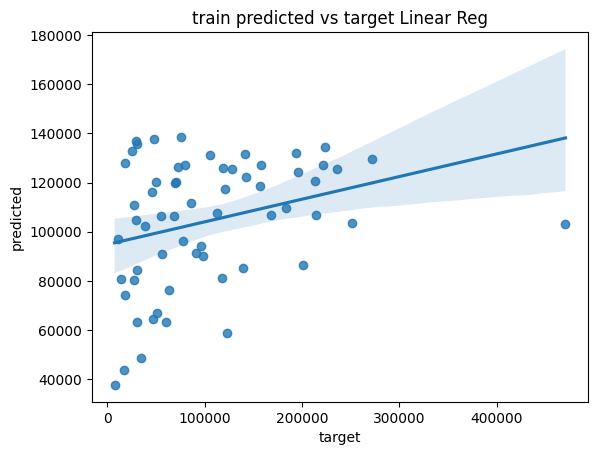

In [48]:
import seaborn as sns
ax = sns.regplot(x=y_train, y= y_train_pred)
ax.set(title = 'train predicted vs target Linear Reg', xlabel='target', ylabel='predicted')


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)


rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
# xgb_model = XGBRegressor(n_estimators=50, random_state=42)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)

# Evaluate the model
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print(f'train mse: {train_mse}')
print(f'test mse: {test_mse}')
print(f'train R^2 Score: {train_r2}')
print(f'test R^2 Score: {test_r2}')

